# Эксперимент XGBoost на подготовленных признаках

Notebook проверяет `xgboost.XGBClassifier` на уже подготовленных признаках из `data/X_train_prepared.csv` и таргете из `data/y_train.csv`.

Данные выравниваются по `source_index`, затем `source_index` удаляется из признаков перед обучением. Notebook ничего не сохраняет на диск: только выводит метрики, таблицы и PR-кривые.

## Зависимость `xgboost`

Для обучения нужен пакет `xgboost`. Если он не установлен в выбранном kernel, notebook остановится с понятной ошибкой и попросит установить пакет явно, например `pip install xgboost`. Автоматически менять окружение notebook не будет.

In [1]:
from pathlib import Path
from collections.abc import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils.class_weight import compute_sample_weight

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    XGBClassifier = None
    XGBOOST_IMPORT_ERROR = exc
else:
    XGBOOST_IMPORT_ERROR = None

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT

WindowsPath('C:/Users/stoli/PycharmProjects/Credit_score')

## Параметры эксперимента

`PRIORITY_CLASSES = [1, 2]` соответствует классам Standard и Good. Для них ниже подбирается threshold: среди точек PR-кривой с `recall >= MIN_RECALL_BY_CLASS` выбирается threshold с максимальным precision.

In [2]:
FEATURES_PATH = PROJECT_ROOT / "data" / "X_train_prepared.csv"
TARGET_PATH = PROJECT_ROOT / "data" / "y_train.csv"
TARGET = "Credit_Score"
INDEX_COLUMN = "source_index"

N_SPLITS = 5
RANDOM_STATE = 42
USE_BALANCED_SAMPLE_WEIGHT = True

CLASS_NAMES_BY_LABEL = {
    "0": "Poor",
    "1": "Standard",
    "2": "Good",
}

PRIORITY_CLASSES = [1, 2]
DEFAULT_MIN_RECALL = 0.50
MIN_RECALL_BY_CLASS = {
    1: 0.50,  # Standard
    2: 0.50,  # Good
}

XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
    "verbosity": 0,
}

## Загрузка и выравнивание данных

`X_train_prepared.csv` и `y_train.csv` соединяются строго один-к-одному по `source_index`. После соединения `source_index` удаляется из `X`, чтобы модель не училась на техническом идентификаторе строки.

In [3]:
def load_aligned_prepared_data(
    features_path: str | Path,
    target_path: str | Path,
    target: str,
    index_column: str,
) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    features = pd.read_csv(features_path)
    target_data = pd.read_csv(target_path)

    missing_feature_columns = {index_column} - set(features.columns)
    if missing_feature_columns:
        raise ValueError(f"В features нет обязательных колонок: {sorted(missing_feature_columns)}")

    missing_target_columns = {index_column, target} - set(target_data.columns)
    if missing_target_columns:
        raise ValueError(f"В target нет обязательных колонок: {sorted(missing_target_columns)}")

    if features[index_column].duplicated().any():
        raise ValueError(f"В features есть дубликаты {index_column}.")
    if target_data[index_column].duplicated().any():
        raise ValueError(f"В target есть дубликаты {index_column}.")

    data = features.merge(
        target_data[[index_column, target]],
        on=index_column,
        how="inner",
        validate="one_to_one",
    )
    if len(data) != len(features) or len(data) != len(target_data):
        raise ValueError(
            "Feature and target files не совпадают по source_index: "
            f"features={len(features)}, target={len(target_data)}, matched={len(data)}"
        )

    source_index = data[index_column].copy()
    y = data[target].copy()
    X = data.drop(columns=[target, index_column]).copy()
    return X, y, source_index


def validate_ready_features(X: pd.DataFrame, y: pd.Series, n_splits: int) -> None:
    if X.empty:
        raise ValueError("Feature matrix is empty.")
    if y.empty:
        raise ValueError("Target vector is empty.")
    if y.isna().any():
        raise ValueError("Target contains missing values.")

    missing_by_column = X.isna().sum()
    missing_by_column = missing_by_column[missing_by_column > 0]
    if not missing_by_column.empty:
        details = missing_by_column.sort_values(ascending=False).head(20).to_dict()
        raise ValueError(f"Ready features must not contain missing values: {details}")

    non_numeric = [column for column in X.columns if not pd.api.types.is_numeric_dtype(X[column])]
    if non_numeric:
        preview = ", ".join(non_numeric[:20])
        raise ValueError(f"Ready features must be numeric. Non-numeric columns: {preview}")

    class_counts = y.value_counts()
    if class_counts.size < 2:
        raise ValueError("Target must contain at least two classes.")

    too_small = class_counts[class_counts < n_splits]
    if not too_small.empty:
        raise ValueError(
            "Each class must have at least n_splits rows for StratifiedKFold. "
            f"Too small classes: {too_small.to_dict()}"
        )


X, y, source_index = load_aligned_prepared_data(FEATURES_PATH, TARGET_PATH, TARGET, INDEX_COLUMN)
validate_ready_features(X, y, N_SPLITS)

display(
    pd.DataFrame(
        {
            "rows": [len(X)],
            "features": [X.shape[1]],
            "classes": [y.nunique()],
            "source_index_removed_from_X": [INDEX_COLUMN not in X.columns],
        }
    )
)
display(y.value_counts().sort_index().rename_axis(TARGET).to_frame("rows"))
display(X.head())

,rows,features,classes,source_index_removed_from_X
0,80000,84,3,True


,rows
Credit_Score,
0,23199
1,42539
2,14262


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Month_Num,Loan_Type_Count,Loan_Type__Auto Loan,Loan_Type__Credit-Builder Loan,Loan_Type__Debt Consolidation Loan,Loan_Type__Home Equity Loan,Loan_Type__Mortgage Loan,Loan_Type__Not Specified,Loan_Type__Payday Loan,Loan_Type__Personal Loan,Loan_Type__Student Loan,debt_to_annual_income,debt_to_monthly_salary,emi_to_monthly_salary,investment_to_monthly_salary,balance_to_monthly_salary,available_income_after_emi,available_income_after_emi_and_investment,delayed_payment_ratio,avg_delay_per_delayed_payment,inquiries_per_credit_account,credit_cards_per_bank_account,loans_per_bank_account,credit_history_years,credit_age_per_loan,total_credit_products,loan_diversity_ratio,has_negative_payment_history,high_utilization_flag,low_balance_flag,debt_per_credit_product,Month_April,Month_August,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Occupation_Accountant,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Credit_Mix_Bad,Credit_Mix_Good,Credit_Mix_Standard,Credit_Mix_Пропуск,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,-0.030611,-0.611964,-0.642510,0.244190,-0.742425,-0.861474,-0.219725,-0.623109,0.985720,-0.393207,-1.505713,-0.554578,0.859029,-0.329758,-0.237681,-0.503647,-0.303578,-0.218091,-0.219659,-0.664802,-0.681172,-0.670319,-0.676692,1.479022,-0.681113,1.459163,-0.673161,1.489693,-0.362890,-0.343246,-0.047387,-0.148815,-0.037083,-0.637288,-0.419101,-0.031142,-0.657871,-1.410209,-0.608467,-0.379271,-0.303578,-0.285421,-0.544451,0.004903,0.038434,1.393106,-0.819264,-0.403018,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.554897,-0.424391,-0.471108,-0.913945,0.225329,0.396244,-0.628211,0.463582,1.065699,1.253837,0.580222,-0.227752,-1.404240,-0.407375,-0.284630,0.022808,-1.419108,0.218168,-0.628165,1.504208,-0.681172,-0.670319,1.477777,-0.676123,-0.681113,-0.685325,-0.673161,-0.671279,-0.306144,-0.282314,-0.217357,-0.190195,0.102000,-0.459395,-0.239079,0.858543,-0.232986,0.727008,0.856331,-0.095708,-1.419108,-0.561860,-0.281714,0.004903,0.038434,-0.717821,-0.819264,-0.102382,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.335468,-1.008337,-0.925790,-0.141855,-0.742425,0.281906,0.188761,-0.079763,0.105948,0.371545,-0.462745,-0.505666,0.822188,-0.580490,-0.266127,-0.530037,0.339611,0.218168,0.188847,-0.664802,-0.681172,-0.670319,-0.676692,1.479022,-0.681113,1.459163,1.485530,-0.671279,0.109602,-0.064747,-0.180854,-0.146947,0.959943,-0.913249,-0.642017,-0.315013,-0.217514,-0.341600,-0.461987,0.131143,0.339611,-0.284447,-0.281714,0.004903,0.038434,1.393106,-0.819264,-0.466594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.172627,0.420220,0.371161,-0.141855,0.709207,0.624920,-0.628211,0.463582,0.745782,-0.217641,-1.505713,-0.511150,0.985891,-0.226477,-0.227643,0.673016,1.475241,0.218168,-0.628165,-0.664802,-0.681172,-0.670319,-0.676692,-0.676123,-0.68

## Вспомогательные функции

Здесь собраны функции для сборки `XGBClassifier`, подсчета macro/weighted метрик, per-class метрик, PR-кривых и threshold tuning для приоритетных классов.

In [4]:
def class_display_name(class_label: object) -> str:
    label_text = str(class_label)
    class_name = CLASS_NAMES_BY_LABEL.get(label_text)
    if class_name:
        return f"{label_text} ({class_name})"
    return label_text


def build_xgb_classifier(num_classes: int):
    if XGBClassifier is None:
        raise ImportError(
            "Пакет xgboost не установлен в текущем окружении. "
            "Установите его явно, например: pip install xgboost, "
            "затем перезапустите kernel. Notebook не устанавливает зависимости автоматически."
        ) from XGBOOST_IMPORT_ERROR

    params = dict(XGB_PARAMS)
    if num_classes > 2:
        params.update(
            {
                "objective": "multi:softprob",
                "num_class": num_classes,
                "eval_metric": "mlogloss",
            }
        )
    else:
        params.update(
            {
                "objective": "binary:logistic",
                "eval_metric": "logloss",
            }
        )
    return XGBClassifier(**params)


def one_vs_rest_targets(y_true: np.ndarray, class_count: int) -> np.ndarray:
    labels = np.arange(class_count)
    if class_count == 2:
        return np.column_stack([(y_true == label).astype(int) for label in labels])
    return label_binarize(y_true, classes=labels)


def roc_auc_metric(y_true: np.ndarray, y_score: np.ndarray, average: str) -> float:
    class_count = y_score.shape[1]
    if class_count == 2:
        return float(roc_auc_score(y_true, y_score[:, 1], average=average))
    return float(
        roc_auc_score(
            y_true,
            y_score,
            labels=np.arange(class_count),
            multi_class="ovr",
            average=average,
        )
    )


def average_precision_metric(y_true: np.ndarray, y_score: np.ndarray, average: str) -> float:
    y_binary = one_vs_rest_targets(y_true, y_score.shape[1])
    return float(average_precision_score(y_binary, y_score, average=average))


def compute_overall_metrics(
    fold: int,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
) -> dict[str, float]:
    return {
        "fold": fold,
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_metric(y_true, y_score, average="macro"),
        "roc_auc_ovr_weighted": roc_auc_metric(y_true, y_score, average="weighted"),
        "average_precision_macro": average_precision_metric(y_true, y_score, average="macro"),
        "average_precision_weighted": average_precision_metric(y_true, y_score, average="weighted"),
    }


def compute_per_class_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
    class_names: Sequence[str],
) -> pd.DataFrame:
    labels = np.arange(len(class_names))
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
    )
    y_binary = one_vs_rest_targets(y_true, len(class_names))

    rows = []
    for class_idx, class_name in enumerate(class_names):
        rows.append(
            {
                "class": class_name,
                "precision": precision[class_idx],
                "recall": recall[class_idx],
                "f1": f1[class_idx],
                "roc_auc_ovr": roc_auc_score(y_binary[:, class_idx], y_score[:, class_idx]),
                "average_precision": average_precision_score(y_binary[:, class_idx], y_score[:, class_idx]),
                "support": support[class_idx],
            }
        )

    return pd.DataFrame(rows).set_index("class")


def curve_frame(precision: np.ndarray, recall: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    padded_thresholds = np.append(thresholds, np.nan)
    return pd.DataFrame(
        {
            "precision": precision,
            "recall": recall,
            "threshold": padded_thresholds,
        }
    )


def compute_pr_curves(y_true: np.ndarray, y_score: np.ndarray, class_names: Sequence[str]) -> dict[str, pd.DataFrame]:
    curves = {}
    y_binary = one_vs_rest_targets(y_true, len(class_names))
    for class_idx, class_name in enumerate(class_names):
        precision, recall, thresholds = precision_recall_curve(
            y_binary[:, class_idx],
            y_score[:, class_idx],
        )
        curves[class_name] = curve_frame(precision, recall, thresholds)
    return curves


def class_label_to_index(class_label: object, label_encoder: LabelEncoder) -> int:
    for class_idx, original_label in enumerate(label_encoder.classes_):
        if class_label == original_label or str(class_label) == str(original_label):
            return class_idx
    known_labels = [str(label) for label in label_encoder.classes_]
    raise ValueError(f"Класс {class_label!r} не найден в target. Доступные классы: {known_labels}")


def min_recall_for_class(class_label: object) -> float:
    lookup_keys = [class_label, str(class_label)]
    if hasattr(class_label, "item"):
        lookup_keys.append(class_label.item())

    for key in lookup_keys:
        if key in MIN_RECALL_BY_CLASS:
            return float(MIN_RECALL_BY_CLASS[key])
    return float(DEFAULT_MIN_RECALL)


def select_threshold_for_precision(
    y_true_binary: np.ndarray,
    y_score_class: np.ndarray,
    min_recall: float,
) -> dict[str, float | bool]:
    precision, recall, thresholds = precision_recall_curve(y_true_binary, y_score_class)
    candidates = pd.DataFrame(
        {
            "threshold": thresholds,
            "precision": precision[:-1],
            "recall": recall[:-1],
        }
    )
    if candidates.empty:
        raise ValueError("Не удалось построить кандидаты threshold для PR-кривой.")

    feasible_candidates = candidates[candidates["recall"] >= min_recall].copy()
    is_feasible = not feasible_candidates.empty
    candidates_for_selection = feasible_candidates if is_feasible else candidates.copy()
    candidates_for_selection["recall_gap"] = (candidates_for_selection["recall"] - min_recall).abs()

    best = candidates_for_selection.sort_values(
        by=["precision", "recall_gap", "threshold"],
        ascending=[False, True, False],
    ).iloc[0]

    return {
        "threshold": float(best["threshold"]),
        "precision_at_threshold": float(best["precision"]),
        "recall_at_threshold": float(best["recall"]),
        "min_recall": float(min_recall),
        "min_recall_satisfied": bool(is_feasible),
    }


def select_priority_thresholds(
    y_true: np.ndarray,
    y_score: np.ndarray,
    label_encoder: LabelEncoder,
    class_names: Sequence[str],
    priority_classes: Sequence[object],
) -> pd.DataFrame:
    y_binary = one_vs_rest_targets(y_true, len(class_names))
    rows = []

    for class_label in priority_classes:
        class_idx = class_label_to_index(class_label, label_encoder)
        row = select_threshold_for_precision(
            y_binary[:, class_idx],
            y_score[:, class_idx],
            min_recall_for_class(class_label),
        )
        row["class_index"] = class_idx
        row["target_label"] = label_encoder.classes_[class_idx]
        row["class"] = class_names[class_idx]
        rows.append(row)

    return pd.DataFrame(rows).set_index("class")


def apply_priority_thresholds(y_score: np.ndarray, thresholds_by_class_index: dict[int, float]) -> np.ndarray:
    adjusted_score = y_score.copy()
    for class_idx, threshold in thresholds_by_class_index.items():
        adjusted_score[:, class_idx] = np.where(
            y_score[:, class_idx] >= threshold,
            y_score[:, class_idx],
            -np.inf,
        )

    adjusted_pred = adjusted_score.argmax(axis=1)
    rows_without_available_class = ~np.isfinite(adjusted_score).any(axis=1)
    if rows_without_available_class.any():
        adjusted_pred[rows_without_available_class] = y_score[rows_without_available_class].argmax(axis=1)
    return adjusted_pred


def prediction_distribution(y_pred: np.ndarray, class_names: Sequence[str]) -> pd.DataFrame:
    counts = pd.Series(y_pred).value_counts().reindex(np.arange(len(class_names)), fill_value=0)
    return pd.DataFrame(
        {
            "class": class_names,
            "rows": counts.to_numpy(),
            "share": counts.to_numpy() / len(y_pred),
        }
    ).set_index("class")

## Обучение и out-of-fold прогнозы

Используется `StratifiedKFold`, чтобы каждая fold сохраняла распределение классов. Метрики считаются на out-of-fold прогнозах, то есть каждая строка оценивается моделью, которая не видела ее при обучении.

In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = [class_display_name(label) for label in label_encoder.classes_]

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
base_model = build_xgb_classifier(len(class_names))

fold_metrics = []
all_y_true = []
all_y_pred = []
all_y_score = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y_encoded), start=1):
    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]
    y_train = y_encoded[train_idx]
    y_valid = y_encoded[valid_idx]

    model = clone(base_model)
    fit_kwargs = {}
    if USE_BALANCED_SAMPLE_WEIGHT:
        fit_kwargs["sample_weight"] = compute_sample_weight(class_weight="balanced", y=y_train)

    model.fit(X_train, y_train, **fit_kwargs)

    y_pred = model.predict(X_valid).astype(int)
    y_score = model.predict_proba(X_valid)
    if y_score.shape[1] != len(class_names):
        raise ValueError(
            f"predict_proba вернул {y_score.shape[1]} колонок, ожидалось {len(class_names)}."
        )

    fold_metrics.append(compute_overall_metrics(fold, y_valid, y_pred, y_score))
    all_y_true.append(y_valid)
    all_y_pred.append(y_pred)
    all_y_score.append(y_score)

y_true_oof = np.concatenate(all_y_true)
y_pred_oof = np.concatenate(all_y_pred)
y_score_oof = np.vstack(all_y_score)

fold_metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
summary_metrics_df = pd.DataFrame(
    {
        "mean": fold_metrics_df.mean(numeric_only=True),
        "std": fold_metrics_df.std(numeric_only=True),
    }
)
per_class_metrics_df = compute_per_class_metrics(y_true_oof, y_pred_oof, y_score_oof, class_names)
pr_curves = compute_pr_curves(y_true_oof, y_score_oof, class_names)

threshold_selection_df = select_priority_thresholds(
    y_true_oof,
    y_score_oof,
    label_encoder,
    class_names,
    PRIORITY_CLASSES,
)
thresholds_by_class_index = threshold_selection_df.set_index("class_index")["threshold"].to_dict()
y_pred_thresholded_oof = apply_priority_thresholds(y_score_oof, thresholds_by_class_index)

argmax_oof_metrics = compute_overall_metrics(0, y_true_oof, y_pred_oof, y_score_oof)
thresholded_oof_metrics = compute_overall_metrics(0, y_true_oof, y_pred_thresholded_oof, y_score_oof)
oof_metrics_comparison_df = pd.DataFrame(
    [argmax_oof_metrics, thresholded_oof_metrics],
    index=["argmax", "thresholded"],
).drop(columns=["fold"])

thresholded_per_class_metrics_df = compute_per_class_metrics(
    y_true_oof,
    y_pred_thresholded_oof,
    y_score_oof,
    class_names,
)
per_class_comparison_df = pd.concat(
    {
        "argmax": per_class_metrics_df,
        "thresholded": thresholded_per_class_metrics_df,
    },
    names=["prediction_rule", "class"],
)

prediction_distribution_comparison_df = pd.concat(
    {
        "argmax": prediction_distribution(y_pred_oof, class_names),
        "thresholded": prediction_distribution(y_pred_thresholded_oof, class_names),
    },
    names=["prediction_rule", "class"],
)

class_names

['0 (Poor)', '1 (Standard)', '2 (Good)']

## Метрики XGBoost с правилом `argmax`

Базовое правило предсказания выбирает класс с максимальной вероятностью. Ниже показаны fold-метрики, среднее и стандартное отклонение по folds, а также per-class метрики на out-of-fold прогнозах.

In [6]:
display(fold_metrics_df.round(4).T)
display(summary_metrics_df.round(4))
display(per_class_metrics_df.round(4).T)

fold,1,2,3,4,5
precision_macro,0.6884,0.6849,0.6767,0.6842,0.6845
precision_weighted,0.7491,0.7467,0.7400,0.7448,0.7466
recall_macro,0.7502,0.7449,0.7370,0.7444,0.7467
recall_weighted,0.7012,0.6983,0.6879,0.6979,0.6956
roc_auc_ovr_macro,0.8799,0.8772,0.8733,0.8788,0.8791
roc_auc_ovr_weighted,0.8629,0.8608,0.8560,0.8625,0.8619
average_precision_macro,0.7645,0.7585,0.7517,0.7633,0.7649
average_precision_weighted,0.7987,0.7938,0.7885,0.7972,0.7976


,mean,std
precision_macro,0.6837,0.0043
precision_weighted,0.7454,0.0034
recall_macro,0.7446,0.0048
recall_weighted,0.6962,0.0051
roc_auc_ovr_macro,0.8776,0.0026
roc_auc_ovr_weighted,0.8608,0.0028
average_precision_macro,0.7606,0.0056
average_precision_weighted,0.7952,0.0042


class,0 (Poor),1 (Standard),2 (Good)
precision,0.6687,0.8630,0.5194
recall,0.7773,0.5972,0.8594
f1,0.7189,0.7059,0.6475
roc_auc_ovr,0.8875,0.8269,0.9185
average_precision,0.7403,0.8647,0.6758
support,23199.0000,42539.0000,14262.0000


## Threshold tuning для Standard и Good

Для классов `1 (Standard)` и `2 (Good)` выбирается threshold, который максимизирует precision при заданном нижнем ограничении на recall. Если достижимой точки с нужным recall нет, `min_recall_satisfied` будет `False`, а threshold будет выбран среди всех доступных точек PR-кривой.

In [7]:
display(
    threshold_selection_df[
        [
            "target_label",
            "class_index",
            "threshold",
            "precision_at_threshold",
            "recall_at_threshold",
            "min_recall",
            "min_recall_satisfied",
        ]
    ].round(4)
)

,target_label,class_index,threshold,precision_at_threshold,recall_at_threshold,min_recall,min_recall_satisfied
class,,,,,,,
1 (Standard),1,1,0.5999,0.9047,0.5005,0.5,True
2 (Good),2,2,0.7127,0.6908,0.5001,0.5,True


## Сравнение `argmax` vs `thresholded`

`thresholded` сначала применяет подобранные thresholds к классам Standard и Good: если вероятность класса ниже threshold, этот класс исключается из выбора для этой строки. После этого выбирается класс с максимальной оставшейся вероятностью; если все классы исключены, используется обычный `argmax` как fallback.

In [8]:
display(oof_metrics_comparison_df.round(4).T)
display(per_class_comparison_df.round(4).T)
display(prediction_distribution_comparison_df.round(4))

,argmax,thresholded
precision_macro,0.6837,0.6867
precision_weighted,0.7454,0.7390
recall_macro,0.7446,0.6416
recall_weighted,0.6962,0.6233
roc_auc_ovr_macro,0.8776,0.8776
roc_auc_ovr_weighted,0.8608,0.8608
average_precision_macro,0.7603,0.7603
average_precision_weighted,0.7950,0.7950


prediction_rule        argmax                          thresholded                         
class                0 (Poor) 1 (Standard)    2 (Good)    0 (Poor) 1 (Standard)    2 (Good)
precision              0.6687       0.8630      0.5194      0.4646       0.9047      0.6908
recall                 0.7773       0.5972      0.8594      0.9242       0.5005      0.5001
f1                     0.7189       0.7059      0.6475      0.6184       0.6444      0.5801
roc_auc_ovr            0.8875       0.8269      0.9185      0.8875       0.8269      0.9185
average_precision      0.7403       0.8647      0.6758      0.7403       0.8647      0.6758
support            23199.0000   42539.0000  14262.0000  23199.0000   42539.0000  14262.0000

rows   share
prediction_rule class                      
argmax          0 (Poor)      26964  0.3370
                1 (Standard)  29438  0.3680
                2 (Good)      23598  0.2950
thresholded     0 (Poor)      46144  0.5768
                1 (Standard)  23531  0.2941
                2 (Good)      10325  0.1291

## PR-кривые

На графике показаны precision-recall curves для всех классов. Для Standard и Good дополнительно отмечены выбранные точки threshold tuning.

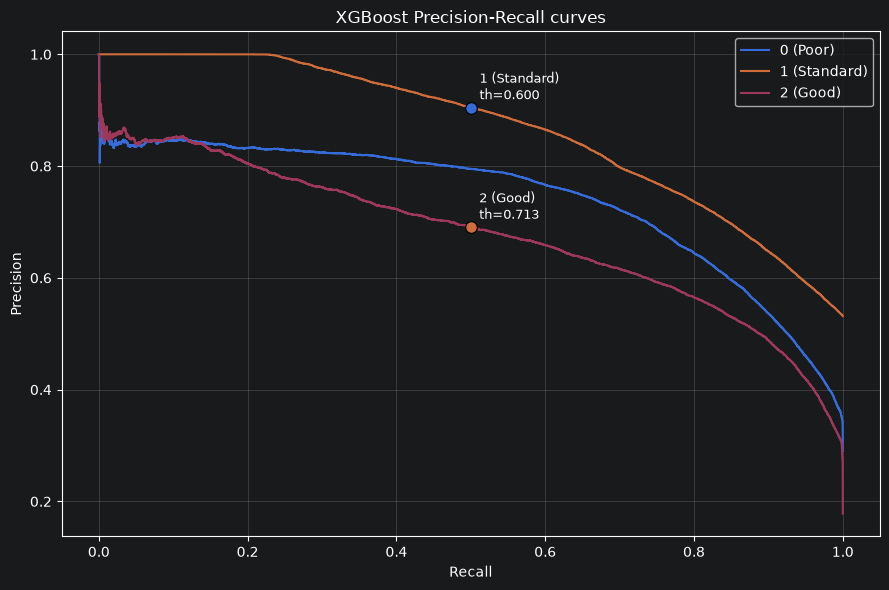

In [9]:
plt.figure(figsize=(9, 6))
for class_name, curve in pr_curves.items():
    plt.plot(curve["recall"], curve["precision"], label=class_name)

for class_name, row in threshold_selection_df.iterrows():
    plt.scatter(
        row["recall_at_threshold"],
        row["precision_at_threshold"],
        s=70,
        marker="o",
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
    )
    plt.annotate(
        f"{class_name}\nth={row['threshold']:.3f}",
        xy=(row["recall_at_threshold"], row["precision_at_threshold"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
pr_curve_points = pd.Series({class_name: len(curve) for class_name, curve in pr_curves.items()}, name="points")
display(pr_curve_points.to_frame())

,points
0 (Poor),79822
1 (Standard),79780
2 (Good),79909
